# Fine-Tune the Two-Tower Model on the Kaggle Student Interaction Dataset (local)

This notebook re-trains the deployed `best_two_tower_model.keras` on
`ml/data/student_learning_interaction_dataset.csv` (simulated, 300 students)
and writes new artifacts back to `ml/models/`.

Correction pass (research-grounded, 2026-09-13):
  - comprehension label mirrors PRODUCTION: the most recent quiz score
    (>=80 Good / >=50 Moderate / else Low), as `comprehension_from_scores`
  - class-balanced (effective-number) + **focal** loss on the comprehension head
  - ordinal penalty (adjacent mislabels cost less than skip errors)
  - task-specific comprehension branch (own Dense(16)) off the shared trunk
  - adjacent-vs-skip error stats

Leakage guard preserved: quiz-derived signals stay OUT of the 7 interaction
features; only the target label changed. Input contract is unchanged.

Run every cell in order. Accuracy / F1 per head appear in the evaluation cell.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import tensorflow as tf
print("TF", tf.__version__)

FOCAL_GAMMA = 1.5
CB_BETA = 0.999
ORDINAL_LAMBDA = 0.1

here = os.path.abspath(".")
if os.path.basename(here) == "src":
    ML = os.path.dirname(here)
elif os.path.basename(here) == "ml":
    ML = here
else:
    ML = os.path.join(here, "ml")
MODELS = os.path.join(ML, "models")
CSV = os.path.join(ML, "data", "student_learning_interaction_dataset.csv")
print("MODELS:", MODELS)


TF 2.21.0
MODELS: C:\Users\myPC\Desktop\FYP\ml\models


In [2]:
df = pd.read_csv(CSV)
df["date"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
print("rows:", len(df), "| nulls:", int(df.isna().sum().sum()))
print("students:", df['student_id'].nunique(), "| modules:", sorted(df['module_id'].unique()))
print("success_label:", df['success_label'].value_counts().to_dict())
df.head()


rows: 9000 | nulls: 0
students: 300 | modules: ['CS101', 'ENG101', 'MATH101', 'PHY101', 'SCI101']
success_label: {1: 7247, 0: 1753}


,student_id,session_id,timestamp,module_id,time_spent_minutes,pages_visited,video_watched_percent,click_events,notes_taken,forum_posts,...,assignment_score,feedback_rating,days_since_last_activity,cumulative_quiz_score,learning_trend,attention_score,feedback_type,next_module_prediction,success_label,date
2339,S0078,S0078_S30,2024-01-02 00:01:00,MATH101,10.111945,8,89.178596,30,0,0,...,96,2,7,2156,71.87,0.11,content_boost,ENG101,0,2024-01-02 00:01:00
1104,S0037,S0037_S25,2024-01-02 00:58:00,ENG101,22.329286,2,94.995588,29,1,1,...,72,4,6,1932,77.28,0.15,revise_prev_topic,PHY101,1,2024-01-02 00:58:00
4899,S0164,S0164_S10,2024-01-02 01:10:00,MATH101,29.936711,10,54.354357,38,1,3,...,73,4,2,724,72.40,0.18,revise_prev_topic,CS101,1,2024-01-02 01:10:00
8797,S0294,S0294_S8,2024-01-02 01:11:00,PHY101,28.166701,12,77.024072,41,0,0,...,83,2,1,615,76.88,0.22,revise_prev_topic,SCI101,1,2024-01-02 01:11:00
1322,S0045,S0045_S3,2024-01-02 01:18:00,CS101,38.342192,4,22.053837,22,0,1,...,80,5,7,240,80.00,0.08,revise_prev_topic,MATH101,1,2024-01-02 01:18:00


In [3]:
end = pd.to_datetime(df['timestamp']).max()
agg = df.groupby(['student_id', 'module_id']).agg(
    total_activities=('time_spent_minutes', 'sum'),
    unique_materials=('pages_visited', 'sum'),
    active_days=('date', lambda s: s.dt.date.nunique()),
    success_rate=('success_label', 'mean'),
    attention_avg=('attention_score', 'mean'),
    learning_trend=('learning_trend', 'mean'),
    sessions=('session_id', 'count'),
    latest_quiz=('quiz_score', 'last'),
    first_ts=('timestamp', 'min'),
    last_ts=('timestamp', 'max'),
).reset_index()

agg['avg_daily_activity'] = agg['total_activities'] / agg['active_days'].clip(lower=1)
span = (pd.to_datetime(agg['last_ts']) - pd.to_datetime(agg['first_ts'])).dt.days.add(1)
agg['activity_per_registered_day'] = agg['total_activities'] / span.clip(lower=1)
agg['days_since_last_activity'] = (end - pd.to_datetime(agg['last_ts'])).dt.days
agg['assessment_count'] = agg['sessions']

FEATURES = ['total_activities', 'unique_materials', 'active_days', 'avg_daily_activity',
            'activity_per_registered_day', 'days_since_last_activity', 'assessment_count']
print("aggregated rows:", len(agg))
agg[FEATURES].describe().T


aggregated rows: 1496


,count,mean,std,min,25%,50%,75%,max
total_activities,1496.0,180.592492,68.657245,18.674500,130.859662,176.319943,224.397142,461.111722
unique_materials,1496.0,48.301471,19.583268,3.000000,35.000000,47.000000,61.000000,115.000000
active_days,1496.0,5.875668,2.086246,1.000000,4.000000,6.000000,7.000000,15.000000
avg_daily_activity,1496.0,30.781374,4.936149,13.688443,27.566061,30.504802,33.649415,50.404283
activity_per_registered_day,1496.0,2.584236,2.741622,0.556746,1.688083,2.202726,2.798898,42.634491
days_since_last_activity,1496.0,18.370321,17.504874,0.000000,5.000000,13.000000,27.000000,105.000000
assessment_count,1496.0,6.016043,2.158535,1.000000,5.000000,6.000000,7.000000,16.000000


In [4]:
def minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else pd.Series(0.0, index=s.index)

composite = (0.30 * minmax(agg['total_activities'])
           + 0.20 * agg['success_rate']
           + 0.20 * minmax(agg['attention_avg'])
           + 0.15 * minmax(agg['learning_trend']))
q1, q2 = composite.quantile([0.40, 0.80])
eng = np.select([composite < q1, composite > q2], [0, 2], default=1)
agg['engagement_class'] = eng.astype(int)
agg['engagement_label'] = np.select([eng == 0, eng == 2],
                                    ['At-Risk', 'Highly Engaged'], default='Moderate')

latest_q = agg['latest_quiz'].fillna(0)
comp = np.select([latest_q >= 80, latest_q >= 50], [2, 1], default=0)
agg['comprehension_class'] = comp.astype(int)
agg['comprehension_label'] = np.select([comp == 2, comp == 1],
                                       ['Good Comprehension', 'Moderate Comprehension'],
                                       default='Low Comprehension')

print("engagement:", agg['engagement_label'].value_counts().to_dict())
print("comprehension:", agg['comprehension_label'].value_counts().to_dict())


engagement: {'Moderate': 599, 'At-Risk': 598, 'Highly Engaged': 299}
comprehension: {'Moderate Comprehension': 893, 'Good Comprehension': 525, 'Low Comprehension': 78}


In [5]:
X = agg[FEATURES].astype(float).values
y_e = agg['engagement_class'].values.astype(int)
y_c = agg['comprehension_class'].values.astype(int)

scaler = StandardScaler()
X_s = scaler.fit_transform(X)

X_tr, X_te, ye_tr, ye_te, yc_tr, yc_te = train_test_split(
    X_s, y_e, y_c, test_size=0.30, random_state=42, stratify=y_e)
X_tr, X_va, ye_tr, ye_va, yc_tr, yc_va = train_test_split(
    X_tr, ye_tr, yc_tr, test_size=0.2142, random_state=42, stratify=ye_tr)
print("train/val/test:", len(X_tr), len(X_va), len(X_te))
print("engagement train dist:", {i: int((ye_tr == i).sum()) for i in range(3)})
print("comprehension train dist:", {i: int((yc_tr == i).sum()) for i in range(3)})


def const_student(n):
    return np.tile(np.array([[1.0, 1.0, 1.0, 5.0, 0.0]], dtype=np.float32), (n, 1))


def sample_weights(y):
    cls, counts = np.unique(y, return_counts=True)
    w = {int(c): float(len(y)) / (len(cls) * int(n)) for c, n in zip(cls, counts)}
    return np.array([w.get(int(v), 1.0) for v in y])


def class_balanced_weights(y, beta=CB_BETA):
    """Cui et al. effective-number-of-samples class weights (mean-normalized)."""
    cls, counts = np.unique(y, return_counts=True)
    n_map = {int(c): int(n) for c, n in zip(cls, counts)}
    raw = {}
    for i in range(3):
        n = n_map.get(i, 0)
        raw[i] = (1.0 - beta) / max(1.0 - beta ** n, 1e-8) if n > 0 else 0.0
    mean_w = sum(raw.values()) / 3 if raw else 1.0
    return {i: raw[i] / mean_w for i in range(3)}


def make_comp_loss(alpha, gamma=FOCAL_GAMMA, lam=ORDINAL_LAMBDA):
    alpha_t = tf.constant([alpha.get(i, 1.0) for i in range(3)], dtype='float32')
    p_range = tf.constant([[0.0, 1.0, 2.0]], dtype='float32')

    def comp_loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true = tf.cast(y_true, tf.int32)
        y_onehot = tf.one_hot(y_true, 3)
        alpha_sel = tf.reduce_sum(y_onehot * alpha_t, axis=-1)
        pt = tf.reduce_sum(y_onehot * y_pred, axis=-1)
        focal = -alpha_sel * tf.pow(1.0 - pt, gamma) * tf.math.log(pt)
        t_f = tf.reduce_sum(y_onehot * tf.constant([0.0, 1.0, 2.0]), axis=-1)
        exp_d = tf.reduce_sum(y_pred * tf.abs(p_range - t_f[:, None]), axis=-1)
        return tf.reduce_mean(focal) + lam * tf.reduce_mean(exp_d)

    return comp_loss


sw_e = sample_weights(ye_tr)
alpha = class_balanced_weights(yc_tr)
print("class-balanced weights:", {i: round(w, 3) for i, w in alpha.items()})
comp_loss = make_comp_loss(alpha)


train/val/test: 822 225 449
engagement train dist: {0: 329, 1: 329, 2: 164}
comprehension train dist: {0: 36, 1: 490, 2: 296}
class-balanced weights: {0: 2.44, 1: 0.223, 2: 0.337}


In [6]:
MODEL_PATH = os.path.join(MODELS, 'best_two_tower_model.keras')
pretrained = os.path.exists(MODEL_PATH)


def build_comp_branch_model(base):
    from tensorflow.keras import layers, Model as KModel
    shared = base.get_layer('engagement_output').input
    comp = layers.Dense(16, activation='relu', name='comp_branch')(shared)
    comp = layers.Dense(3, activation='softmax', name='comprehension_output')(comp)
    return KModel(inputs=base.inputs,
                  outputs=[base.get_layer('engagement_output').output, comp])


if pretrained:
    model = build_comp_branch_model(tf.keras.models.load_model(MODEL_PATH))
    print("Loaded deployed model -> fine-tuning (new comprehension branch)")
else:
    from tensorflow.keras import layers, Model

    def tower(inp):
        x = layers.Dense(64, activation='relu')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dense(32, activation='relu')(x)
        return x

    student = layers.Input(shape=(5,), name='student_input')
    interaction = layers.Input(shape=(7,), name='interaction_input')
    x = layers.Concatenate()([tower(student), tower(interaction)])
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    eng = layers.Dense(3, activation='softmax', name='engagement_output')(x)
    comp = layers.Dense(16, activation='relu', name='comp_branch')(x)
    comp = layers.Dense(3, activation='softmax', name='comprehension_output')(comp)
    model = Model(inputs=[student, interaction], outputs=[eng, comp])
    print("Built fresh Two-Tower (same contract)")
model.summary()


Loaded deployed model -> fine-tuning (new comprehension branch)


C:\Users\myPC\Desktop\FYP\venv\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam_1', because it has 42 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ student_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interaction_input   │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        384 │ student_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        512 │ interaction_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ comp_branch (Dense) │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engagement_output   │ (None, 3)         │         99 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ comprehension_outp… │ (None, 3)         │         51 │ comp_branch[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,326 (32.52 KB)

 Trainable params: 8,070 (31.52 KB)

 Non-trainable params: 256 (1.00 KB)

In [7]:
if pretrained:
    try:
        with open(os.path.join(MODELS, 'oulad_preprocessor.json'), 'r', encoding='utf-8') as fh:
            dep = json.load(fh)
        X_old = (X - np.array(dep['mean'])) / np.array(dep['scale'])
        pe0, _ = model.predict([const_student(len(X)), X_old.astype(np.float32)], verbose=0)
        c0 = {i: int((pe0.argmax(1) == i).sum()) for i in range(3)}
        print("Deployed model before fine-tune (on these rows):", c0)
    except FileNotFoundError:
        print("(old oulad_preprocessor.json not present - skipping before/after contrast)")
else:
    print("(no pretrained model to contrast)")


Deployed model before fine-tune (on these rows): {0: 644, 1: 483, 2: 369}


In [8]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss={
                  'engagement_output': 'sparse_categorical_crossentropy',
                  'comprehension_output': comp_loss,
              },
              metrics={'engagement_output': 'accuracy', 'comprehension_output': 'accuracy'})

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6),
]

history = model.fit(
    [const_student(len(X_tr)), X_tr.astype(np.float32)],
    [ye_tr, yc_tr],
    validation_data=([const_student(len(X_va)), X_va.astype(np.float32)], [ye_va, yc_va]),
    sample_weight=[sw_e, np.ones(len(yc_tr))],
    epochs=120, batch_size=32, callbacks=callbacks, verbose=1)

print("best val_loss: %.4f" % min(history.history['val_loss']))


Epoch 1/120


 1/26 ━━━━━━━━━━━━━━━━━━━━ 1:48 4s/step - comprehension_output_accuracy: 0.1875 - comprehension_output_loss: 0.3895 - engagement_output_accuracy: 0.6562 - engagement_output_loss: 0.6488 - loss: 1.0383

18/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - comprehension_output_accuracy: 0.2604 - comprehension_output_loss: 0.3476 - engagement_output_accuracy: 0.6684 - engagement_output_loss: 0.6781 - loss: 1.0256 

26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - comprehension_output_accuracy: 0.2956 - comprehension_output_loss: 0.3320 - engagement_output_accuracy: 0.6557 - engagement_output_loss: 0.7081 - loss: 1.0399 - val_comprehension_output_accuracy: 0.5156 - val_comprehension_output_loss: 0.3505 - val_engagement_output_accuracy: 0.6667 - val_engagement_output_loss: 0.6396 - val_loss: 1.0586 - learning_rate: 0.0010


Epoch 2/120


...

Epoch 16/120


 1/26 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - comprehension_output_accuracy: 0.5312 - comprehension_output_loss: 0.2369 - engagement_output_accuracy: 0.7188 - engagement_output_loss: 0.7068 - loss: 0.9437

21/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - comprehension_output_accuracy: 0.4301 - comprehension_output_loss: 0.2752 - engagement_output_accuracy: 0.6741 - engagement_output_loss: 0.6777 - loss: 0.9529 

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - comprehension_output_accuracy: 0.4355 - comprehension_output_loss: 0.2754 - engagement_output_accuracy: 0.6752 - engagement_output_loss: 0.6745 - loss: 0.9492 - val_comprehension_output_accuracy: 0.4800 - val_comprehension_output_loss: 0.3637 - val_engagement_output_accuracy: 0.6844 - val_engagement_output_loss: 0.6398 - val_loss: 1.0931 - learning_rate: 2.5000e-04


best val_loss: 1.0586


In [9]:
pe, pc = model.predict([const_student(len(X_te)), X_te.astype(np.float32)], verbose=0)
p_e, p_c = pe.argmax(1), pc.argmax(1)

eng_acc = float(accuracy_score(ye_te, p_e))
eng_f1 = float(f1_score(ye_te, p_e, average='macro'))
comp_acc = float(accuracy_score(yc_te, p_c))
comp_f1 = float(f1_score(yc_te, p_c, average='macro'))

diff_c = np.abs(p_c - yc_te)
comp_errors = int((diff_c > 0).sum())
comp_adjacent = int((diff_c == 1).sum())
comp_skip = int((diff_c == 2).sum())

print("Engagement    accuracy: %.4f   macro-F1: %.4f" % (eng_acc, eng_f1))
print("Comprehension accuracy: %.4f   macro-F1: %.4f" % (comp_acc, comp_f1))
print("Comprehension errors: %d total | %d adjacent | %d skip" % (comp_errors, comp_adjacent, comp_skip))
print()
print("Engagement report:")
print(classification_report(ye_te, p_e, target_names=['At-Risk', 'Moderate', 'Highly Engaged'], zero_division=0))
print("Comprehension report:")
print(classification_report(yc_te, p_c, target_names=['Low Comprehension', 'Moderate Comprehension', 'Good Comprehension'], zero_division=0))


Engagement    accuracy: 0.6370   macro-F1: 0.6287
Comprehension accuracy: 0.4521   macro-F1: 0.3086
Comprehension errors: 246 total | 220 adjacent | 26 skip

Engagement report:
                precision    recall  f1-score   support

       At-Risk       0.70      0.80      0.75       179
      Moderate       0.60      0.42      0.49       180
Highly Engaged       0.57      0.76      0.65        90

      accuracy                           0.64       449
     macro avg       0.62      0.66      0.63       449
  weighted avg       0.63      0.64      0.62       449

Comprehension report:
                        precision    recall  f1-score   support

     Low Comprehension       0.07      0.14      0.09        28
Moderate Comprehension       0.58      0.64      0.61       266
    Good Comprehension       0.29      0.18      0.22       155

              accuracy                           0.45       449
             macro avg       0.31      0.32      0.31       449
          weighted a

In [10]:
pe_all, pc_all = model.predict([const_student(len(X)), X_s.astype(np.float32)], verbose=0)
print("fine-tuned engagement distribution:", {i: int((pe_all.argmax(1) == i).sum()) for i in range(3)})
print("fine-tuned comprehension distribution:", {i: int((pc_all.argmax(1) == i).sum()) for i in range(3)})


def sanity(label, feats):
    z = scaler.transform([feats])[0]
    pe_i, pc_i = model.predict([const_student(1), np.array([z], dtype=np.float32)], verbose=0)
    e = ['At-Risk', 'Moderate', 'Highly Engaged'][int(pe_i.argmax())]
    c = ['Low', 'Moderate', 'Good'][int(pc_i.argmax())]
    print("%-16s -> eng=%-14s %s  comp=%s %s" % (label, e, np.round(pe_i[0], 3), c, np.round(pc_i[0], 3)))


sanity('inactive', [0, 0, 0, 0, 0, 200, 0])
sanity('moderate', [41.15, 30, 5, 8.23, 3.7, 0, 3])
sanity('heavy',    [1200, 300, 40, 45.0, 120.0, 0, 8])


fine-tuned engagement distribution: {0: 670, 1: 432, 2: 394}
fine-tuned comprehension distribution: {0: 198, 1: 989, 2: 309}
inactive         -> eng=At-Risk        [1. 0. 0.]  comp=Good [0.157 0.06  0.783]
moderate         -> eng=At-Risk        [1. 0. 0.]  comp=Moderate [0.029 0.513 0.458]


heavy            -> eng=Highly Engaged [0. 0. 1.]  comp=Good [0.002 0.287 0.711]


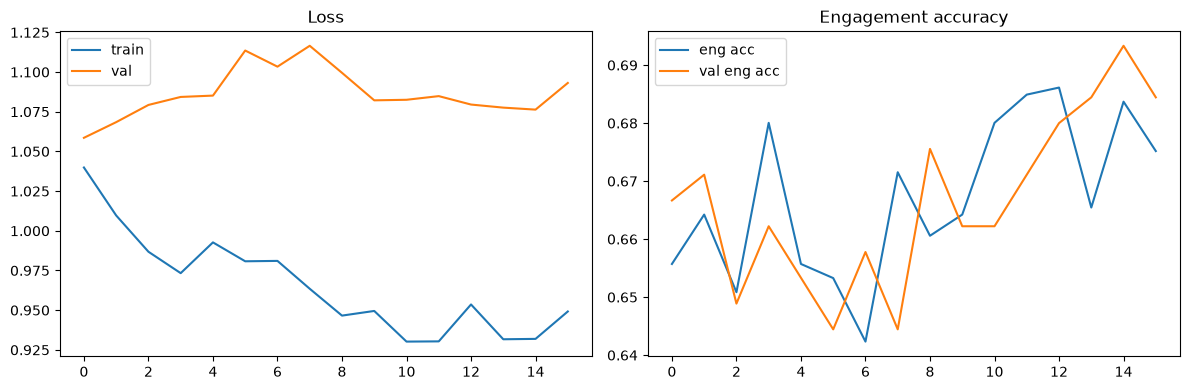

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
h = history.history
axes[0].plot(h['loss'], label='train')
axes[0].plot(h['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(h.get('engagement_output_accuracy', []), label='eng acc')
axes[1].plot(h.get('val_engagement_output_accuracy', []), label='val eng acc')
axes[1].set_title('Engagement accuracy')
axes[1].legend()
fig.tight_layout()
fig.savefig(os.path.join(MODELS, 'training_curves.png'))
plt.show()


In [12]:
prep = {
    'mean': [float(m) for m in scaler.mean_],
    'scale': [float(s) for s in scaler.scale_],
    'feature_names': FEATURES,
}
with open(os.path.join(MODELS, 'oulad_preprocessor.json'), 'w', encoding='utf-8') as fh:
    json.dump(prep, fh, indent=4)

contract = {
    'student_features': ['gender', 'age_band', 'highest_education', 'imd_band', 'disability'],
    'interaction_features': FEATURES,
    'targets': {
        'engagement': ['At-Risk', 'Moderate', 'Highly Engaged'],
        'comprehension': ['Low Comprehension', 'Moderate Comprehension', 'Good Comprehension'],
    },
}
with open(os.path.join(MODELS, 'oulad_feature_contract.json'), 'w', encoding='utf-8') as fh:
    json.dump(contract, fh, indent=4)

# Recompile with standard losses so the saved artifact loads anywhere
# (test_inference.py, backend) without custom-object registration.
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=['sparse_categorical_crossentropy', 'sparse_categorical_crossentropy'],
              metrics={'engagement_output': 'accuracy', 'comprehension_output': 'accuracy'})
model.save(MODEL_PATH)

lines = [
    'Engagement    accuracy: %.4f' % eng_acc,
    'Engagement    macro-F1: %.4f' % eng_f1,
    'Comprehension accuracy: %.4f' % comp_acc,
    'Comprehension macro-F1: %.4f' % comp_f1,
    'Comprehension errors: %d total | %d adjacent | %d skip' % (comp_errors, comp_adjacent, comp_skip),
    'comprehension label: latest quiz score (>=80 Good, >=50 Moderate, else Low) - matches production comprehension_from_scores',
    'comprehension loss: class-balanced focal (gamma=%.1f) + ordinal (lam=%.1f)' % (FOCAL_GAMMA, ORDINAL_LAMBDA),
    'class-balanced beta: %.3f' % CB_BETA,
    'curves: training_curves.png',
    'source: Kaggle student-learning-interaction-logs-dataset (simulated, 300 students)',
    'method: fine-tuned from deployed best_two_tower_model.keras',
]
with open(os.path.join(MODELS, 'training_report.txt'), 'w', encoding='utf-8') as fh:
    fh.write('\n'.join(lines) + '\n')

metrics = {
    'engagement_accuracy': eng_acc,
    'engagement_f1_macro': eng_f1,
    'comprehension_accuracy': comp_acc,
    'comprehension_f1_macro': comp_f1,
    'comprehension_errors': comp_errors,
    'comprehension_adjacent_errors': comp_adjacent,
    'comprehension_skip_errors': comp_skip,
    'loss_params': {'focal_gamma': FOCAL_GAMMA, 'class_balanced_beta': CB_BETA, 'ordinal_lambda': ORDINAL_LAMBDA},
    'comprehension_label_source': 'latest_quiz',
    'classes_engagement': {i: int((pe_all.argmax(1) == i).sum()) for i in range(3)},
    'classes_comprehension': {i: int((pc_all.argmax(1) == i).sum()) for i in range(3)},
}
with open(os.path.join(MODELS, 'model_evaluation_results.json'), 'w', encoding='utf-8') as fh:
    json.dump(metrics, fh, indent=4)

print("artifacts written to", MODELS)
print(sorted(os.listdir(MODELS)))


artifacts written to C:\Users\myPC\Desktop\FYP\ml\models
['archive_pre_kaggle_20260913', 'archive_pre_labelfix_20260913', 'best_two_tower_model.keras', 'model_evaluation_results.json', 'oulad_feature_contract.json', 'oulad_preprocessor.json', 'training_curves.png', 'training_report.txt']


## Result / next steps
- The test accuracy + macro-F1 above are on the 30% holdout (stratified).
- Comprehension errors are split into adjacent (Low<->Moderate, Moderate<->Good)
  vs skip (Low<->Good) so the ordinal behaviour is visible.
- Artifacts updated: `best_two_tower_model.keras`, `oulad_preprocessor.json`, `oulad_feature_contract.json`.
- The calibration layer in the backend stays intact; the frontend picks up the
  new model after the backend restarts (it caches the model at startup).